In [1]:
import numpy as np
from sklearn.datasets import make_blobs
from matplotlib import pyplot as plt

Pour implémenter de bout en bout notre modèle du perceptron, nous allons générer un dataset contenant n = 50 enregistrements possédant chacun m = 2 caractéristiques avec une étiquette binaire y ∈ {0, 1}.

In [2]:
# Generation d'un dataset fictif
X, y = make_blobs(n_samples=50, n_features=2, centers=2, random_state=0)

# Creation du vecteur unitaire pour le biais
unit_vector = np.ones(X.shape[0], int)
unit_vector = unit_vector.reshape((unit_vector.shape[0], 1))

# Reformatage de la matrice des features et du vecteur target
X = np.concatenate((X, unit_vector), axis=1)
y = y.reshape((y.shape[0], 1))

Le dataset a été généré grâce à la fonction make blobs() du package sklearn. Dans la Figure 3, nous repre ́sentons les données générées sur un nuage de points habillés selon les classes de la variable à prédire. Il en ressort que les deux classes sont linéairement sépérables, ce qui est compatible avec le modèle du perceptron développé dans la sous-section

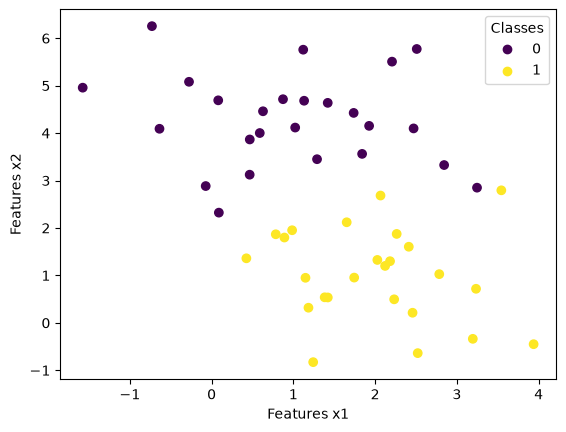

In [3]:
scatter_plot = plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel('Features x1')
plt.ylabel('Features x2')
plt.legend(* scatter_plot.legend_elements(), loc='best', title='Classes')

Pour programmer le modèle du perceptron, le code Python sera structuré comme suit :

— Initialisation des paramètres comme point de départ de l’algorithme de la descente du gradient.

— Codage des équations fondamentales du modèle (cf. système 7).

— Évaluation du coût obtenu au niveau de l’itération en cours.

— Mise à jour des paramètres si la variation du coût à l’itération en cours n’est pas nulle.

— Répétition en boucle des deux dernières étapes jusqu’à minimiser la fonction-coût.

### Définition de la fonction d’initialisation
Elle permettra de fixer ale ́atoirement les parame`tres initiaux de l’algorithme d’optimisation.

In [4]:
# Fonction d'initialisation
def initialize(X):
    np.random.seed(6)
    W = np.random.randn(X.shape[1], 1)
    return W

### Definition des fonctions d'agregation et d'activation
Elles permettront de retourner la probabilite ́ qu’un enregistrement appartienne a` la classe de re ́fe ́rence de la variable cible

In [5]:
# Equations fondamentales
def model(X, W):
    Z = X.dot(W)
    A = 1 / (1 + np.exp(-Z))
    return A

### Definition de la fonction-cout
Elle permettra de calculer l'ecart moyen entre les probabilites predites et les vraies valeurs de la variable cible.

In [6]:
# Fonction-cout
def log_loss(A, y):
    L= -1/len(y) * np.sum((y * np.log(A)) + ((1-y) * np.log(1-A)))
    return L

### Definition du vecteur jacobien
Il permettra de mesurer la variation de la fonction-cout par rapport aux parametres obtenus dans une iteration donnee.

In [7]:
# Vecteur des gradients Jacobien
def gradients(A, X, y):
    J = 1/len(y) * np.dot(X.T, (A - y))
    return J

### Definition de la fonction de mise a jour
Elle permettra de rafraichir les parametres du modele de sorte a minimiser les erreurs de prediction

In [8]:
# Actualisation des parametres
def update(J, W, learning_rate):
    W = W - learning_rate * J
    return W

Apre`s avoir code ́ toutes les e ́quations en Python, proce ́dons a` pre ́sent au codage de l’algorithme d’optimisation. Ce code permettra de visualiser l’e ́volution de la valeur du couˆt a` travers les ite ́rations, et de retourner les valeurs optimales des parame`tres du mode`le. Le taux d’apprentissage dans l’e ́quation du gradient est fixe ́ a` α = 0.1 et le nombre d’ite ́rations a` H = 100.

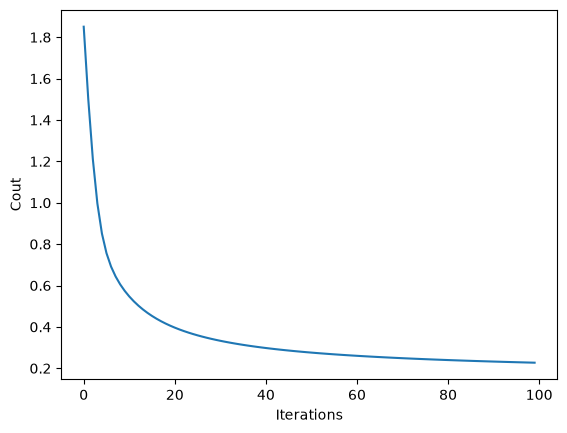

w1: 1.0164185659842155
w2: -1.0704961794165886
b : 0.8128297688531373


In [13]:
# Algorithme d’optimisation
def perceptron(X, y, learning_rate, n_iterations):
    W = initialize(X)
    L = []
    
    for h in range(n_iterations):
        A = model(X, W)
        L.append(log_loss(A, y)) 
        J = gradients(A, X, y)
        W = update(J, W, learning_rate)
        
    plt.plot(L) 
    plt.xlabel('Iterations') 
    plt.ylabel('Cout') 
    plt.show()

    return W

# Entrainement du modele
W = perceptron(X, y, learning_rate = .1, n_iterations = 100) 
print("w1:", W[0][0])
print("w2:", W[1][0])
print("b :", W[2][0])

définir une fonction qui permettra de prédire la classe d’appartenance des enregistrements sur base de la régle définie dans l’expression 3. Ensuite, nous calculerons la performance du modèle, i.e. sa capacité à prédire fidèlement la classe d’appartenance d’un enregistrement étiquette ́.

In [14]:
# Fonction de prediction
def predict(X, W):
    A = model(X, W)
    y_pred = []
    for i in range(X.shape[0]):
        if A[i] >= .5:
            y_pred.append(1)
        else:
            y_pred.append(0)
    return y_pred

y_pred = predict(X, W)

In [23]:
# Matrice de confusion
def confusion_matrix(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    n_classes = np.unique(y_true).shape[0]
    confusion_matrix = np.zeros((n_classes, n_classes))
    
    for i in range(len(y_true)):
        confusion_matrix[y_true[i], y_pred[i]] += 1
        
    return confusion_matrix

# 1. Générer la matrice de confusion brute (Scikit-Learn)
# y_true: les vraies étiquettes, y_pred: les prédictions de votre modèle
cm = confusion_matrix(y_true = y, y_pred = y_pred)
print(cm)

[[23.  2.]
 [ 4. 21.]]


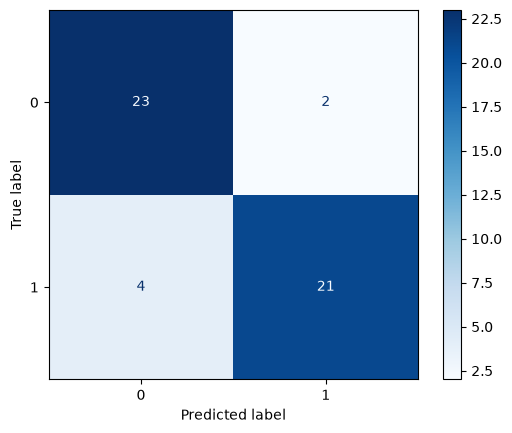

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y, y_pred, cmap="Blues")
plt.show()

In [24]:
# Accuracy
def accuracy(confusion_matrix):
    diag = np.diag(confusion_matrix, k = 0)
    n_correct = diag.sum()
    n_total = confusion_matrix.sum()
    accuracy = n_correct / n_total
    return accuracy
Acc = accuracy(cm)
print(Acc)

0.88


Text(-1.5, 2, 'Frontiere \nde decision')

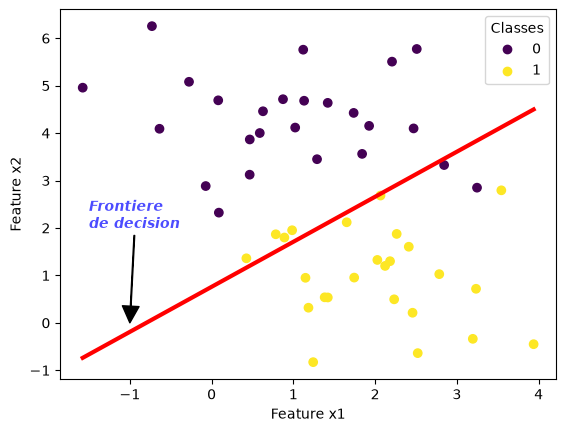

In [29]:
# Fontiere de decision
scatter_plot = plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel('Feature x1')
plt.ylabel('Feature x2')
plt.legend(*scatter_plot.legend_elements(), 
           loc='best', 
           title='Classes')

x_line = np.linspace(min(X[:, 0]), max(X[:, 0]), num = 100)
y_line = -1/W[1] * (W[0] * x_line + W[2])
plt.plot(x_line, y_line, c= 'red', lw = 3)

plt.annotate('Frontiere \nde decision', 
             (-1,0), xytext = (-1.5,2), 
             arrowprops = dict(facecolor = 'black', width = .5), 
             fontstyle = 'oblique', 
             weight = 'bold', 
             fontsize = 10, 
             color = 'blue', 
             alpha = .7)